## CALCULATE THE DISTANCE BETWEEN THE ORIGINAL, THE RANDOM and OUR GENERATOR

In [ ]:
!pip install umap-learn

In [1]:
import plotly.io as pio
pio.renderers.default = 'notebook'

In [2]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import OrdinalEncoder
from scipy.spatial import distance
from sklearn.manifold import TSNE

import altair as alt
alt.data_transformers.enable('default', max_rows=None)

DataTransformerRegistry.enable('default')

In [3]:
## import the ordinal encoded dataset
df = pd.read_csv('../../datasets/enc_dataset.csv')
df_ourgen = pd.read_csv('../../datasets/ordinal_neighbourhood.csv')

In [4]:
#import the one-hot-encoded random df
df_random=pd.read_csv('../../datasets/random_n_dataset.csv')
df_random.head()

,Week6_Covid=NONE,Week6_Covid=AND,Week6_Covid=LMM,Week6_Covid=HM,Week6_Covid=HMM,Week5_Covid=NONE,Week5_Covid=AND,Week5_Covid=LMM,Week5_Covid=HM,Week5_Covid=HMM,...,Week2_Mobility=NONE,Week2_Mobility=NM,Week2_Mobility=SH,Week2_Mobility=DM,Week2_Mobility=IM,Week1_Mobility=NONE,Week1_Mobility=NM,Week1_Mobility=SH,Week1_Mobility=DM,Week1_Mobility=IM
0,0,0,0,0,1,0,0,0,1,0,...,1,0,0,0,0,0,0,1,0,0
1,0,0,0,1,0,0,0,1,0,0,...,0,0,0,0,1,0,1,0,0,0
2,0,1,0,0,0,0,0,0,0,1,...,0,0,0,0,1,1,0,0,0,0
3,0,1,0,0,0,0,0,0,1,0,...,1,0,0,0,0,1,0,0,0,0
4,1,0,0,0,0,1,0,0,0,0,...,0,0,0,1,0,0,0,0,1,0


In [5]:
df=df.drop("Class_label", axis=1)

In [6]:
df= df.astype(int)

In [7]:
df.head()

,Week6_Covid,Week5_Covid,Week4_Covid,Week3_Covid,Week2_Covid,Week1_Covid,Week6_Mobility,Week5_Mobility,Week4_Mobility,Week3_Mobility,Week2_Mobility,Week1_Mobility
0,1,1,0,0,0,0,1,1,0,0,0,0
1,1,1,1,1,1,1,1,1,1,1,1,1
2,2,2,2,2,2,2,2,3,3,3,3,3
3,0,0,0,1,1,1,0,0,0,1,1,1
4,1,1,1,1,1,1,1,1,1,1,1,1


In [8]:
data_np=df.to_numpy()

#### Change the one hot encoded structure df

In [9]:
# Initialize an empty DataFrame
decoded_random_df = pd.DataFrame(index=df_random.index)

# Loop over each column and process
for column in df_random.columns:
    col_name, col_value = column.split('=')  # Split the column name

    
    # Check where the original DataFrame has a 1 (i.e., is 'hot'), and set that value
    decoded_random_df.loc[df_random[column] == 1, col_name] = col_value
decoded_random_df.head()

,Week6_Covid,Week5_Covid,Week4_Covid,Week3_Covid,Week2_Covid,Week1_Covid,Week6_Mobility,Week5_Mobility,Week4_Mobility,Week3_Mobility,Week2_Mobility,Week1_Mobility
0,HMM,HM,AND,LMM,AND,NONE,NM,DM,NONE,IM,NONE,SH
1,HM,LMM,AND,LMM,HMM,HMM,NM,IM,SH,DM,IM,NM
2,AND,HMM,AND,NONE,NONE,HM,DM,SH,IM,NONE,IM,NONE
3,AND,HM,HM,LMM,AND,LMM,SH,NONE,NONE,SH,NONE,NONE
4,NONE,NONE,HMM,LMM,HMM,HMM,SH,DM,NM,SH,DM,DM


In [10]:
decoded_random_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Week6_Covid     100 non-null    object
 1   Week5_Covid     100 non-null    object
 2   Week4_Covid     100 non-null    object
 3   Week3_Covid     100 non-null    object
 4   Week2_Covid     100 non-null    object
 5   Week1_Covid     100 non-null    object
 6   Week6_Mobility  100 non-null    object
 7   Week5_Mobility  100 non-null    object
 8   Week4_Mobility  100 non-null    object
 9   Week3_Mobility  100 non-null    object
 10  Week2_Mobility  100 non-null    object
 11  Week1_Mobility  100 non-null    object
dtypes: object(12)
memory usage: 9.5+ KB


In [11]:
#### Ordinal encode the random df

covid_categories = ['NONE', 'AND', 'LMM', 'HM', 'HMM']
mobility_categories = ['NONE', 'NM', 'DM', 'SH', 'IM']

enc = OrdinalEncoder(categories=[covid_categories for i in range(6)] + [mobility_categories for i in range(6)])
 
enc_random= enc.fit_transform(decoded_random_df)

enc_random_df = pd.DataFrame(enc_random)
enc_random_df.columns = df.columns.tolist()

In [12]:
enc_random_df.head()

,Week6_Covid,Week5_Covid,Week4_Covid,Week3_Covid,Week2_Covid,Week1_Covid,Week6_Mobility,Week5_Mobility,Week4_Mobility,Week3_Mobility,Week2_Mobility,Week1_Mobility
0,4.0,3.0,1.0,2.0,1.0,0.0,1.0,2.0,0.0,4.0,0.0,3.0
1,3.0,2.0,1.0,2.0,4.0,4.0,1.0,4.0,3.0,2.0,4.0,1.0
2,1.0,4.0,1.0,0.0,0.0,3.0,2.0,3.0,4.0,0.0,4.0,0.0
3,1.0,3.0,3.0,2.0,1.0,2.0,3.0,0.0,0.0,3.0,0.0,0.0
4,0.0,0.0,4.0,2.0,4.0,4.0,3.0,2.0,1.0,3.0,2.0,2.0


In [13]:
enc_random_df= enc_random_df.astype(int)

In [14]:
enc_random_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Week6_Covid     100 non-null    int64
 1   Week5_Covid     100 non-null    int64
 2   Week4_Covid     100 non-null    int64
 3   Week3_Covid     100 non-null    int64
 4   Week2_Covid     100 non-null    int64
 5   Week1_Covid     100 non-null    int64
 6   Week6_Mobility  100 non-null    int64
 7   Week5_Mobility  100 non-null    int64
 8   Week4_Mobility  100 non-null    int64
 9   Week3_Mobility  100 non-null    int64
 10  Week2_Mobility  100 non-null    int64
 11  Week1_Mobility  100 non-null    int64
dtypes: int64(12)
memory usage: 9.5 KB


In [15]:
enc_random_np=enc_random_df.to_numpy()

In [16]:
df_ourgen.head()

,Week6_Covid,Week5_Covid,Week4_Covid,Week3_Covid,Week2_Covid,Week1_Covid,Week6_Mobility,Week5_Mobility,Week4_Mobility,Week3_Mobility,Week2_Mobility,Week1_Mobility
0,3,2,2,1,3,4,3,4,4,4,4,4
1,3,2,1,2,3,2,3,3,2,3,4,4
2,1,1,2,2,1,1,2,2,1,1,4,3
3,3,1,3,3,1,4,1,1,1,1,2,2
4,1,4,3,3,2,3,1,1,2,3,3,2


In [17]:
ourgen_np=df_ourgen.to_numpy()

In [18]:
ourgen_np

array([[3, 2, 2, ..., 4, 4, 4],
       [3, 2, 1, ..., 3, 4, 4],
       [1, 1, 2, ..., 1, 4, 3],
       ...,
       [1, 3, 3, ..., 2, 2, 1],
       [1, 3, 4, ..., 1, 1, 2],
       [3, 3, 3, ..., 4, 2, 2]])

### COMPUTE THE DISTANCE

In [19]:
#Distances between original data and generates neigh
dist_matrix = distance.cdist(data_np, ourgen_np, 'euclidean')

# Find the index of the closest vector in generates neigh for each vector in the original data
closest_indices = np.argmin(dist_matrix, axis=1)
closest_vectors = ourgen_np[closest_indices]

In [20]:
similarity_scores = np.sum(dist_matrix, axis=0)

In [21]:
similarity_scores

array([2824.39315214, 2311.41609795, 2031.01972236, 1835.39023441,
       1962.85821829, 2006.92080179, 1996.72830378, 2076.00590575,
       2292.71166367, 1756.64578747, 1735.39083812, 2508.25896125,
       2286.19399483, 1862.73471526, 2450.96178494, 2204.47854669,
       1735.7352941 , 1988.19304579, 2393.84713047, 2585.39063346,
       2457.87735866, 1849.68546167, 2219.50126347, 2013.48457773,
       2201.43622508, 2270.55701157, 2070.93914844, 1848.13139355,
       1802.01889259, 2236.49407054, 1649.33085761, 2150.54172873,
       2037.89322511, 2371.49498292, 2418.33164814, 2614.33405099,
       2039.74492528, 2053.52654261, 2149.93694208, 1694.18624333,
       2402.05985978, 2455.87699672, 1806.5880331 , 2014.5215784 ,
       2319.47516497, 1954.56641227, 2019.6642393 , 1913.74634248,
       1624.18513678, 1613.17533978, 2272.16429706, 1747.7813204 ,
       2362.93306585, 2003.52804701, 2099.2276264 , 1957.38718736,
       2485.8607265 , 2466.28644677, 2234.65200926, 2978.47053

In [22]:
sorted_indices = np.argsort(similarity_scores)
m3 = ourgen_np[sorted_indices[::-1]]  # m3 is m2 sorted by decreasing similarity

In [23]:
m3

array([[2, 2, 3, ..., 4, 4, 4],
       [3, 2, 2, ..., 4, 4, 4],
       [3, 3, 3, ..., 4, 4, 1],
       ...,
       [1, 1, 1, ..., 2, 2, 2],
       [1, 1, 2, ..., 1, 1, 3],
       [2, 2, 2, ..., 2, 2, 1]])

In [24]:
#Distances between original data and generates neigh
dist_matrix_r = distance.cdist(data_np, enc_random_np, 'euclidean')

# Find the index of the closest vector in generates neigh for each vector in the original data
closest_indices = np.argmin(dist_matrix, axis=1)
closest_vectors_r = enc_random_np[closest_indices]

In [25]:
similarity_scores_r = np.sum(dist_matrix_r, axis=0)

In [26]:
similarity_scores_r

array([2464.92343218, 2392.97822861, 2761.52536644, 2167.46016426,
       2397.16481706, 2619.36208839, 1944.76000911, 2543.47489384,
       2065.2181087 , 1941.99377964, 2393.93612407, 2539.6583562 ,
       2327.99881959, 2687.91147586, 2828.32298067, 2398.73180717,
       2543.93001293, 2498.27433733, 2410.59286347, 1884.87631093,
       2057.96940199, 2444.4817595 , 2724.63751271, 2723.23025248,
       2671.30490681, 1937.23689234, 2326.85311182, 2567.84228835,
       2116.44506729, 2339.36521865, 2477.18581639, 2658.62186982,
       2108.48209401, 2285.91441129, 2788.06745537, 2183.50306948,
       2929.54684917, 2540.31206095, 2401.17395387, 2384.29560544,
       2714.04494797, 2078.33728551, 2486.03862068, 2396.39037777,
       2573.99544281, 2368.62864203, 3011.01673823, 2412.11873024,
       2650.78721438, 2770.24756006, 2347.2684273 , 1909.19810248,
       2113.43073605, 2276.27995324, 2624.46733674, 2150.9843234 ,
       2215.25255009, 2333.5082065 , 2759.66581116, 2649.22492

In [27]:
sorted_indices_r = np.argsort(similarity_scores_r)
m4 = enc_random_np[sorted_indices_r[::-1]]  # m3 is m2 sorted by decreasing similarity

In [28]:
m4

array([[0, 0, 0, ..., 4, 4, 0],
       [4, 3, 4, ..., 3, 4, 0],
       [4, 0, 3, ..., 4, 4, 4],
       ...,
       [2, 1, 2, ..., 2, 1, 1],
       [3, 3, 1, ..., 1, 2, 1],
       [3, 1, 2, ..., 2, 2, 1]])

In [29]:
enc_random_df['source']='random'
df_ourgen['source']='our'
df['source']='original'

In [30]:
combined_df = pd.concat([df, df_ourgen, enc_random_df], axis=0)

In [31]:
combined_df.head()

,Week6_Covid,Week5_Covid,Week4_Covid,Week3_Covid,Week2_Covid,Week1_Covid,Week6_Mobility,Week5_Mobility,Week4_Mobility,Week3_Mobility,Week2_Mobility,Week1_Mobility,source
0,1,1,0,0,0,0,1,1,0,0,0,0,original
1,1,1,1,1,1,1,1,1,1,1,1,1,original
2,2,2,2,2,2,2,2,3,3,3,3,3,original
3,0,0,0,1,1,1,0,0,0,1,1,1,original
4,1,1,1,1,1,1,1,1,1,1,1,1,original


### TSNE

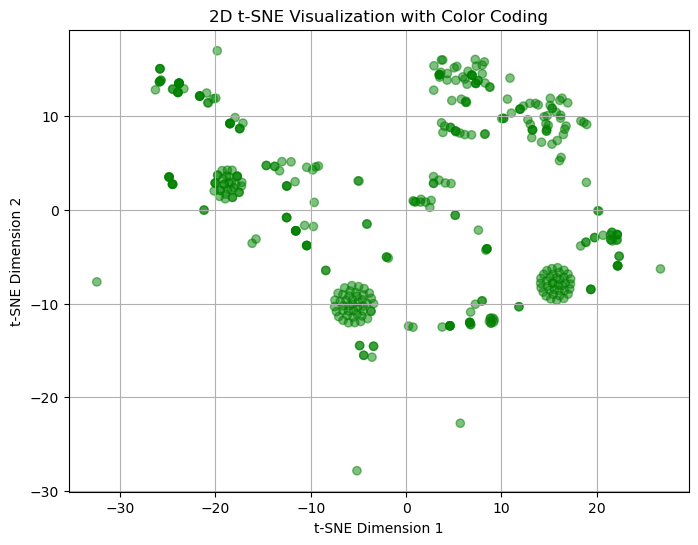

In [51]:
combined_data = np.vstack((data_np, enc_random_np, ourgen_np))

# Initialize t-SNE object with desired parameters
tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42)

# Fit t-SNE on the first array (data_np) and transform combined data
embedded_data = tsne.fit_transform(data_np)

# Define colors for each array
color_data = ['green'] * len(data_np)
color_random = ['red'] * len(enc_random_np)
color_ourgen = ['blue'] * len(ourgen_np)

# Concatenate color lists
colors = color_data + color_random + color_ourgen

# Plot 2D t-SNE visualization with color coding
plt.figure(figsize=(8, 6))
plt.scatter(embedded_data[:, 0], embedded_data[:, 1], c=colors[:len(embedded_data)], alpha=0.5)
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.title('2D t-SNE Visualization with Color Coding')
plt.grid(True)
plt.show()

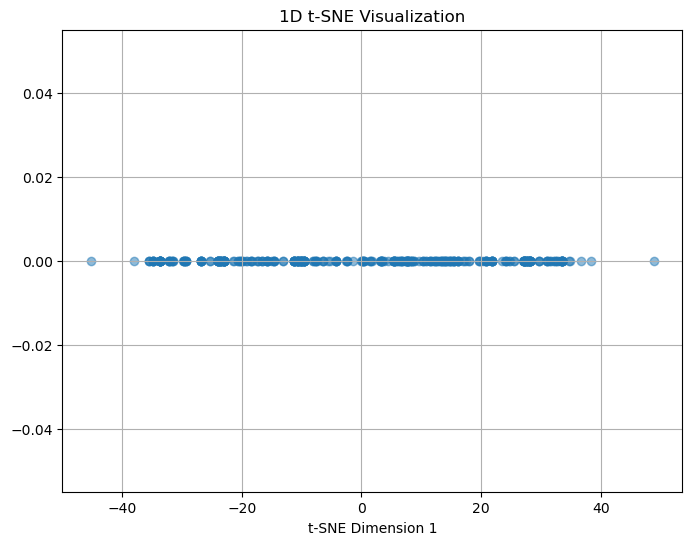

In [48]:
# Initialize t-SNE object with 3 components
tsne_1d = TSNE(n_components=1, perplexity=30, n_iter=1000, random_state=42)

# Fit t-SNE on the first array (data_np) and transform combined data
embedded_data_1d = tsne_1d.fit_transform(data_np)
plt.figure(figsize=(8, 6))
plt.scatter(embedded_data_1d[:, 0], np.zeros_like(embedded_data_1d[:, 0]), alpha=0.5)
plt.xlabel('t-SNE Dimension 1')
plt.title('1D t-SNE Visualization')
plt.grid(True)
plt.show()

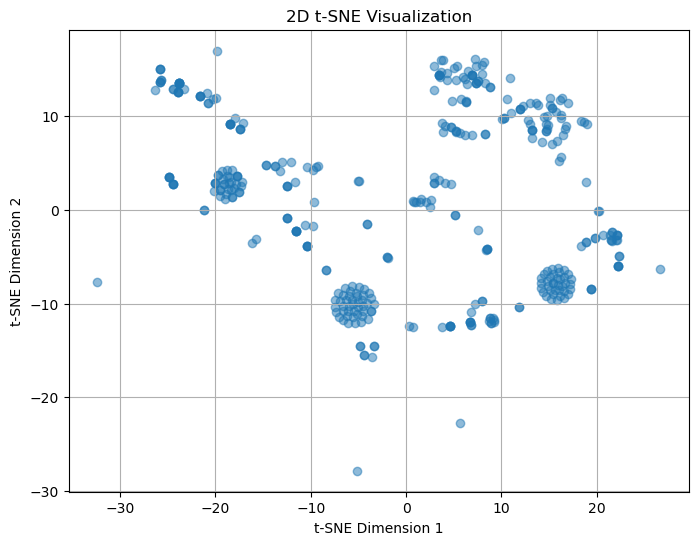

In [40]:
plt.figure(figsize=(8, 6))
plt.scatter(embedded_data[:, 0], embedded_data[:, 1], alpha=0.5)
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.title('2D t-SNE Visualization')
plt.grid(True)
plt.show()

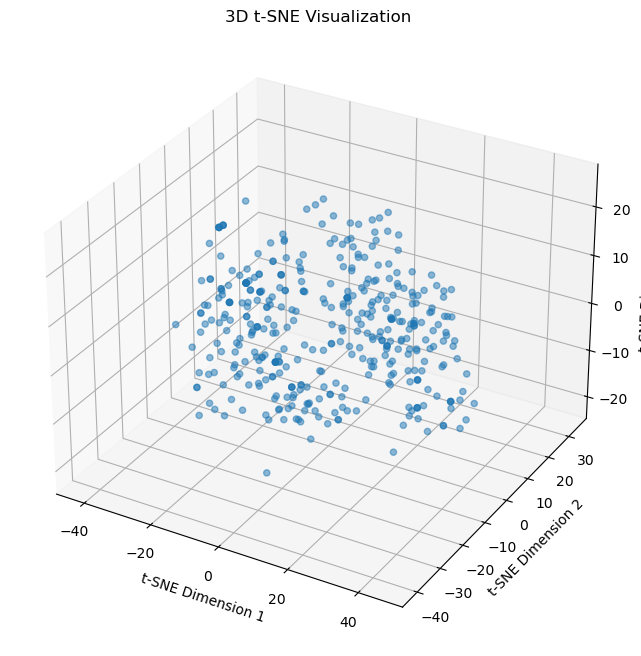

In [47]:
# Initialize t-SNE object with 3 components
tsne_3d = TSNE(n_components=3, perplexity=30, n_iter=1000, random_state=42)

# Fit t-SNE on the first array (data_np) and transform combined data
embedded_data_3d = tsne_3d.fit_transform(data_np)

from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(embedded_data_3d[:, 0], embedded_data_3d[:, 1], embedded_data_3d[:, 2], alpha=0.5)
ax.set_xlabel('t-SNE Dimension 1')
ax.set_ylabel('t-SNE Dimension 2')
ax.set_zlabel('t-SNE Dimension 3')
ax.set_title('3D t-SNE Visualization')
plt.show()

In [42]:
import plotly.graph_objs as go

trace = go.Scatter3d(
    x=embedded_data[:, 0],
    y=embedded_data[:, 1],
    z=embedded_data[:, 2],
    mode='markers',
    marker=dict(
        size=5,
        opacity=0.5
    )
)

layout = go.Layout(
    title='3D t-SNE Visualization',
    scene=dict(
        xaxis=dict(title='t-SNE Dimension 1'),
        yaxis=dict(title='t-SNE Dimension 2'),
        zaxis=dict(title='t-SNE Dimension 3')
    )
)

fig = go.Figure(data=[trace], layout=layout)
fig.show()

IndexError: index 2 is out of bounds for axis 1 with size 2

## UMap

In [ ]:
enc_random_df.info()

In [ ]:
from umap import UMAP

In [ ]:
import plotly.express as px

In [ ]:
features=combined_df.loc[:,:'Week1_Mobility']

umap2d=UMAP(n_components=2, init='random', random_state=0)
proj_2d=umap2d.fit_transform(features)
fig_2d = px.scatter(
    proj_2d, x=0,y=1,
    color=combined_df.source, labels={'color':'source'}
)

fig_2d.show()

### OLD STUFF

In [ ]:
'''
# Combine two np
combined_data = np.vstack((data_np, ourgen_np,))

# Perform T-SNE
tsne = TSNE(n_components=2, random_state=0)
transformed_data = tsne.fit_transform(combined_data)

# Plot
plt.figure(figsize=(10, 8))
plt.scatter(transformed_data[:len(data_np), 0], transformed_data[:len(data_np), 1], color='red', label='original data')
plt.scatter(transformed_data[len(data_np):, 0], transformed_data[len(data_np):, 1], color='blue', label='our data')
plt.legend()
plt.title('T-SNE Visualization of original data and ourdata')
plt.show()
'''

In [ ]:
'''
# Combine two np
combined_data = np.vstack((data_np, enc_random_np))

# Perform T-SNE
tsne = TSNE(n_components=2, random_state=0)
transformed_data = tsne.fit_transform(combined_data)

# Plot
plt.figure(figsize=(10, 8))
plt.scatter(transformed_data[:len(data_np), 0], transformed_data[:len(data_np), 1], color='red', label='original data')
plt.scatter(transformed_data[len(data_np):, 0], transformed_data[len(data_np):, 1], color='blue', label='random data')
plt.legend()
plt.title('T-SNE Visualization of original data and ourdata')
plt.show()
'''